# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score, precision_recall_curve)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

import warnings
warnings.filterwarnings('ignore')

In [2]:
class Config:
    """Centralized configuration"""
    SEED = 42
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15
    BATCH_SIZE = 128  # Increased for better GPU utilization
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 150
    PATIENCE = 20
    HIDDEN_DIMS = [256, 128, 64, 32]  # Deeper architecture
    DROPOUT_RATES = [0.5, 0.4, 0.3, 0.2]
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Risk thresholds for decision making
    APPROVE_THRESHOLD = 0.7
    REVIEW_THRESHOLD = 0.4

# Set random seeds
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"🚀 Device: {Config.DEVICE}")

🚀 Device: cuda


# Load data

In [3]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
# Update path to your file location
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 148670 rows, 34 columns


# Data analyzer

In [5]:
class DataAnalyzer:
    """Comprehensive data analysis and quality reporting"""

    def __init__(self, df):
        self.df = df
        self.report = {}

    def generate_report(self):
        """Generate full data quality report"""
        print("="*70)
        print("📊 DATA QUALITY REPORT")
        print("="*70)

        self._basic_info()
        self._missing_values()
        self._target_analysis()
        self._numeric_features()
        self._categorical_features()
        self._detect_outliers()

        return self.report

    def _basic_info(self):
        print(f"\n1️⃣ BASIC INFORMATION")
        print(f"   • Total rows: {len(self.df):,}")
        print(f"   • Total columns: {len(self.df.columns)}")
        print(f"   • Memory usage: {self.df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    def _missing_values(self):
        print(f"\n2️⃣ MISSING VALUES")
        missing = self.df.isnull().sum()
        missing_pct = (missing / len(self.df)) * 100

        missing_df = pd.DataFrame({
            'Count': missing.values,
            'Percentage': missing_pct.values
        }, index=missing.index)
        missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)

        if len(missing_df) > 0:
            print(f"   • Columns with missing: {len(missing_df)}")
            for col, row in missing_df.head(10).iterrows():
                status = "🔴" if row['Percentage'] > 50 else "🟡" if row['Percentage'] > 20 else "🟢"
                print(f"     {status} {col}: {row['Count']} ({row['Percentage']:.1f}%)")
            self.report['missing_values'] = missing_df
        else:
            print("   ✅ No missing values!")

    def _target_analysis(self):
        print(f"\n3️⃣ TARGET VARIABLE")
        target_col = self._find_target_column()

        if target_col:
            value_counts = self.df[target_col].value_counts()
            print(f"   • Target: '{target_col}'")
            for val, count in value_counts.items():
                pct = (count / len(self.df)) * 100
                print(f"     - {val}: {count:,} ({pct:.1f}%)")

            imbalance = value_counts.max() / value_counts.min()
            print(f"   • Imbalance ratio: {imbalance:.2f}:1")
            if imbalance > 3:
                print(f"   ⚠️  Significant class imbalance!")

            self.report['target_distribution'] = value_counts
            self.report['imbalance_ratio'] = imbalance

    def _numeric_features(self):
        print(f"\n4️⃣ NUMERIC FEATURES")
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        print(f"   • Count: {len(numeric_cols)}")
        self.report['numeric_columns'] = list(numeric_cols)

    def _categorical_features(self):
        print(f"\n5️⃣ CATEGORICAL FEATURES")
        cat_cols = self.df.select_dtypes(include=['object', 'category']).columns
        print(f"   • Count: {len(cat_cols)}")
        for col in cat_cols[:5]:
            n_unique = self.df[col].nunique()
            print(f"     {col}: {n_unique} unique values")
        self.report['categorical_columns'] = list(cat_cols)

    def _detect_outliers(self):
        print(f"\n6️⃣ OUTLIER DETECTION")
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        outlier_summary = {}

        for col in numeric_cols[:10]:
            Q1, Q3 = self.df[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            outliers = self.df[(self.df[col] < Q1 - 1.5*IQR) | (self.df[col] > Q3 + 1.5*IQR)]
            outlier_pct = len(outliers) / len(self.df) * 100

            if outlier_pct > 1:
                print(f"   • {col}: {len(outliers)} ({outlier_pct:.1f}%)")
                outlier_summary[col] = len(outliers)

        self.report['outliers'] = outlier_summary

    def _find_target_column(self):
        """Find target column"""
        candidates = ['Status', 'status', 'loan_status', 'default', 'Default']
        for col in candidates:
            if col in self.df.columns:
                return col
        return None

# Data preprocessing

In [6]:
class AdvancedPreprocessor:
    """Advanced preprocessing pipeline"""

    def __init__(self):
        self.label_encoders = {}
        self.scaler = None
        self.feature_columns = []
        self.imputer = None

    def fit_transform(self, df, target_col='Status'):
        """Complete preprocessing pipeline"""
        print("\n" + "="*70)
        print("🔧 PREPROCESSING PIPELINE")
        print("="*70)

        df_processed = df.copy()

        # 1. Handle missing values
        df_processed = self._handle_missing(df_processed, target_col)

        # 2. Feature engineering
        df_processed = self._engineer_features(df_processed)

        # 3. Encode categoricals
        df_processed = self._encode_categoricals(df_processed, target_col)

        # 4. Prepare features
        X, y, self.feature_columns = self._prepare_features(df_processed, target_col)

        print(f"\n✅ Preprocessing complete!")
        print(f"   • Features: {len(self.feature_columns)}")
        print(f"   • Samples: {len(X):,}")

        return X, y

    def _handle_missing(self, df, target_col):
        """Smart missing value handling"""
        print("\n📋 Handling missing values...")

        # Separate features and target
        if target_col in df.columns:
            y = df[target_col]
            X = df.drop(columns=[target_col])
        else:
            X = df
            y = None

        # Numeric columns - use KNN imputation
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.imputer = KNNImputer(n_neighbors=5)
            X[numeric_cols] = self.imputer.fit_transform(X[numeric_cols])
            print(f"   • Imputed {len(numeric_cols)} numeric columns")

        # Categorical columns - use mode
        cat_cols = X.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            if X[col].isnull().any():
                mode_val = X[col].mode()
                fill_val = mode_val[0] if len(mode_val) > 0 else 'Unknown'
                X[col].fillna(fill_val, inplace=True)

        if y is not None:
            X[target_col] = y

        return X

    def _engineer_features(self, df):
        """Create engineered features"""
        print("\n⚙️ Engineering features...")

        # Debt-to-income ratio
        if 'loan_amount' in df.columns and 'income' in df.columns:
            df['debt_to_income'] = df['loan_amount'] / (df['income'] + 1)

        # Credit utilization
        if 'Credit_Score' in df.columns:
            df['credit_quality'] = pd.cut(df['Credit_Score'],
                                         bins=[0, 580, 670, 740, 850],
                                         labels=['Poor', 'Fair', 'Good', 'Excellent'])

        # LTV risk categories
        if 'LTV' in df.columns:
            df['ltv_risk'] = pd.cut(df['LTV'],
                                   bins=[0, 80, 90, 100, 200],
                                   labels=['Low', 'Medium', 'High', 'Very High'])

        # Age handling
        if 'age' in df.columns:
            age_mapping = {
                '<25': 22, '25-34': 29.5, '35-44': 39.5,
                '45-54': 49.5, '55-64': 59.5, '65-74': 69.5, '>74': 77
            }
            df['age_numeric'] = df['age'].map(age_mapping) if df['age'].dtype == 'object' else df['age']
            df['age_numeric'].fillna(df['age_numeric'].median(), inplace=True)

        print(f"   • Created engineered features")
        return df

    def _encode_categoricals(self, df, target_col):
        """Encode categorical variables"""
        print("\n🔢 Encoding categorical variables...")

        cat_cols = df.select_dtypes(include=['object', 'category']).columns
        cat_cols = [col for col in cat_cols if col != target_col]

        for col in cat_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
                self.label_encoders[col] = le

        # Encode target
        if target_col in df.columns:
            le_target = LabelEncoder()
            df['target'] = le_target.fit_transform(df[target_col])
            self.label_encoders['target'] = le_target
            print(f"   • Encoded {len(cat_cols)} features + target")

        return df

    def _prepare_features(self, df, target_col):
        """Prepare final feature matrix"""
        # Exclude original categorical and target columns
        exclude_cols = list(self.label_encoders.keys()) + [target_col, 'target']

        numeric_cols = df.select_dtypes(include=[np.number]).columns
        feature_cols = [col for col in numeric_cols if col not in exclude_cols]

        # Add encoded columns
        encoded_cols = [f'{col}_encoded' for col in self.label_encoders.keys()
                       if col != 'target' and f'{col}_encoded' in df.columns]
        feature_cols.extend(encoded_cols)

        # Remove duplicates
        feature_cols = list(dict.fromkeys(feature_cols))

        X = df[feature_cols].values
        y = df['target'].values if 'target' in df.columns else df[target_col].values

        return X, y, feature_cols


# Model

In [7]:
class ImprovedCreditRiskNN(nn.Module):
    """Enhanced Neural Network with Residual Connections"""

    def __init__(self, input_dim, hidden_dims=[256, 128, 64, 32], dropout_rates=[0.5, 0.4, 0.3, 0.2]):
        super(ImprovedCreditRiskNN, self).__init__()

        self.input_bn = nn.BatchNorm1d(input_dim)

        # Layer 1
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        self.dropout1 = nn.Dropout(dropout_rates[0])

        # Layer 2
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.dropout2 = nn.Dropout(dropout_rates[1])

        # Layer 3
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        self.dropout3 = nn.Dropout(dropout_rates[2])

        # Layer 4
        self.fc4 = nn.Linear(hidden_dims[2], hidden_dims[3])
        self.bn4 = nn.BatchNorm1d(hidden_dims[3])
        self.dropout4 = nn.Dropout(dropout_rates[3])

        # Output layer
        self.fc_out = nn.Linear(hidden_dims[3], 1)

        self._init_weights()

    def _init_weights(self):
        """Xavier initialization"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.input_bn(x)

        # Layer 1
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        # Layer 2
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        # Layer 3
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)

        # Layer 4
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)

        # Output
        x = torch.sigmoid(self.fc_out(x))

        return x

# Train model

In [9]:
class Trainer:
    """Enhanced training with callbacks and monitoring"""

    def __init__(self, model, train_loader, val_loader, config):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config

        # Calculate class weights for imbalanced data
        self.criterion = nn.BCELoss()

        self.optimizer = optim.AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY,
            betas=(0.9, 0.999)
        )

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
        )

        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': [],
            'val_precision': [], 'val_recall': [], 'val_f1': []
        }

        self.best_val_loss = float('inf')
        self.best_model_state = None
        self.patience_counter = 0

    def train_epoch(self):
        """Train one epoch"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_X, batch_y in self.train_loader:
            batch_X = batch_X.to(self.config.DEVICE)
            batch_y = batch_y.to(self.config.DEVICE)

            self.optimizer.zero_grad()
            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        return running_loss / len(self.train_loader), correct / total

    def validate_epoch(self):
        """Validate one epoch"""
        self.model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch_X, batch_y in self.val_loader:
                batch_X = batch_X.to(self.config.DEVICE)
                batch_y = batch_y.to(self.config.DEVICE)

                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)

                running_loss += loss.item()
                predicted = (outputs > 0.5).float()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        all_preds = np.array(all_preds).flatten()
        all_labels = np.array(all_labels).flatten()

        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, zero_division=0)
        recall = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)

        return running_loss / len(self.val_loader), acc, precision, recall, f1

    def train(self):
        """Full training loop"""
        print("\n" + "="*70)
        print("🚀 TRAINING STARTED")
        print("="*70)

        for epoch in range(self.config.NUM_EPOCHS):
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc, val_prec, val_rec, val_f1 = self.validate_epoch()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_precision'].append(val_prec)
            self.history['val_recall'].append(val_rec)
            self.history['val_f1'].append(val_f1)

            self.scheduler.step(val_loss)

            # Save best model
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model_state = self.model.state_dict().copy()
                self.patience_counter = 0
            else:
                self.patience_counter += 1

            # Print progress
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{self.config.NUM_EPOCHS}]")
                print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
                print(f"  Val: Loss={val_loss:.4f}, Acc={val_acc:.4f}, F1={val_f1:.4f}")
                print(f"  LR={self.optimizer.param_groups[0]['lr']:.6f}")
                print("-"*70)

            # Early stopping
            if self.patience_counter >= self.config.PATIENCE:
                print(f"\n⚠️ Early stopping at epoch {epoch+1}")
                break

        # Load best model
        if self.best_model_state:
            self.model.load_state_dict(self.best_model_state)
            print(f"\n✅ Loaded best model (val_loss={self.best_val_loss:.4f})")

        return self.history

# Evaluate model

In [10]:
class ModelEvaluator:
    """Comprehensive model evaluation"""

    def __init__(self, model, test_loader, device):
        self.model = model
        self.test_loader = test_loader
        self.device = device

    def evaluate(self):
        """Full evaluation with metrics and visualizations"""
        print("\n" + "="*70)
        print("📊 MODEL EVALUATION")
        print("="*70)

        self.model.eval()
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            for batch_X, batch_y in self.test_loader:
                batch_X = batch_X.to(self.device)
                outputs = self.model(batch_X).cpu().numpy()

                all_probs.extend(outputs.flatten())
                all_preds.extend((outputs > 0.5).astype(int).flatten())
                all_labels.extend(batch_y.numpy().flatten())

        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)
        all_labels = np.array(all_labels)

        # Calculate metrics
        metrics = {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'roc_auc': roc_auc_score(all_labels, all_probs)
        }

        print(f"\n📈 Performance Metrics:")
        print(f"  • Accuracy:  {metrics['accuracy']*100:.2f}%")
        print(f"  • Precision: {metrics['precision']*100:.2f}%")
        print(f"  • Recall:    {metrics['recall']*100:.2f}%")
        print(f"  • F1 Score:  {metrics['f1']*100:.2f}%")
        print(f"  • ROC AUC:   {metrics['roc_auc']*100:.2f}%")

        # Confusion matrix
        cm = confusion_matrix(all_labels, all_preds)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['High Risk', 'Low Risk'],
                   yticklabels=['High Risk', 'Low Risk'])
        plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

        return metrics, all_probs, all_labels

# Make prediction

In [12]:
class RiskPredictor:
    """Production-ready risk prediction system"""

    def __init__(self, model, preprocessor, scaler, config):
        self.model = model
        self.preprocessor = preprocessor
        self.scaler = scaler
        self.config = config
        self.model.eval()

    def predict(self, application_data):
        """Predict credit risk for loan application"""
        # Prepare features
        features = self._prepare_input(application_data)

        # Scale
        features_scaled = self.scaler.transform(features)

        # Predict
        with torch.no_grad():
            features_tensor = torch.FloatTensor(features_scaled).to(self.config.DEVICE)
            risk_prob = self.model(features_tensor).cpu().item()

        # Decision logic
        if risk_prob >= self.config.APPROVE_THRESHOLD:
            decision = 'APPROVED'
            recommendation = '✅ Low risk - Approve with standard terms'
            risk_level = 'LOW'
        elif risk_prob >= self.config.REVIEW_THRESHOLD:
            decision = 'UNDER REVIEW'
            recommendation = '⚠️ Moderate risk - Additional verification required'
            risk_level = 'MEDIUM'
        else:
            decision = 'REJECTED'
            recommendation = '❌ High risk - Reject or require collateral'
            risk_level = 'HIGH'

        return {
            'risk_score': risk_prob,
            'risk_percentage': risk_prob * 100,
            'risk_level': risk_level,
            'decision': decision,
            'recommendation': recommendation,
            'confidence': abs(risk_prob - 0.5) * 2  # 0 to 1 scale
        }

    def _prepare_input(self, data):
        """Prepare input features from application data"""
        features = []
        for col in self.preprocessor.feature_columns:
            if col.endswith('_encoded'):
                orig_col = col.replace('_encoded', '')
                if orig_col in self.preprocessor.label_encoders:
                    try:
                        val = self.preprocessor.label_encoders[orig_col].transform([data.get(orig_col, 'Unknown')])[0]
                    except:
                        val = 0
                    features.append(val)
            elif col == 'age_numeric':
                features.append(data.get('age_numeric', data.get('age', 35)))
            else:
                features.append(data.get(col, 0))

        return np.array(features, dtype=np.float32).reshape(1, -1)

# Main

📊 DATA QUALITY REPORT

1️⃣ BASIC INFORMATION
   • Total rows: 148,670
   • Total columns: 34
   • Memory usage: 173.90 MB

2️⃣ MISSING VALUES
   • Columns with missing: 14
     🟡 Upfront_charges: 39642.0 (26.7%)
     🟡 Interest_rate_spread: 36639.0 (24.6%)
     🟡 rate_of_interest: 36439.0 (24.5%)
     🟢 dtir1: 24121.0 (16.2%)
     🟢 property_value: 15098.0 (10.2%)
     🟢 LTV: 15098.0 (10.2%)
     🟢 income: 9150.0 (6.2%)
     🟢 loan_limit: 3344.0 (2.2%)
     🟢 approv_in_adv: 908.0 (0.6%)
     🟢 submission_of_application: 200.0 (0.1%)

3️⃣ TARGET VARIABLE
   • Target: 'Status'
     - 0: 112,031 (75.4%)
     - 1: 36,639 (24.6%)
   • Imbalance ratio: 3.06:1
   ⚠️  Significant class imbalance!

4️⃣ NUMERIC FEATURES
   • Count: 13

5️⃣ CATEGORICAL FEATURES
   • Count: 21
     loan_limit: 2 unique values
     Gender: 4 unique values
     approv_in_adv: 2 unique values
     loan_type: 3 unique values
     loan_purpose: 4 unique values

6️⃣ OUTLIER DETECTION
   • loan_amount: 1895 (1.3%)
   • U

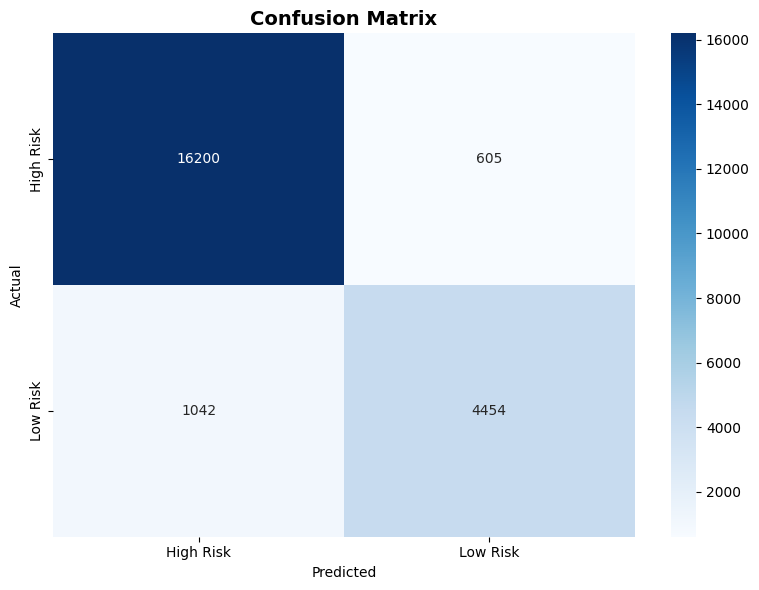

In [13]:
analyzer = DataAnalyzer(df)
report = analyzer.generate_report()

# 2. Preprocess data
preprocessor = AdvancedPreprocessor()
X, y = preprocessor.fit_transform(df, target_col='Status')

# 3. Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=Config.TEST_SIZE + Config.VAL_SIZE,
    random_state=Config.SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    random_state=Config.SEED, stratify=y_temp
)

# 4. Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Create data loaders
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.FloatTensor(y_train).reshape(-1, 1)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val).reshape(-1, 1)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test).reshape(-1, 1)
)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE)

# 6. Create and train model
model = ImprovedCreditRiskNN(
    input_dim=X_train_scaled.shape[1],
    hidden_dims=Config.HIDDEN_DIMS,
    dropout_rates=Config.DROPOUT_RATES
).to(Config.DEVICE)

trainer = Trainer(model, train_loader, val_loader, Config)
history = trainer.train()

# 7. Evaluate model
evaluator = ModelEvaluator(model, test_loader, Config.DEVICE)
metrics, probs, labels = evaluator.evaluate()



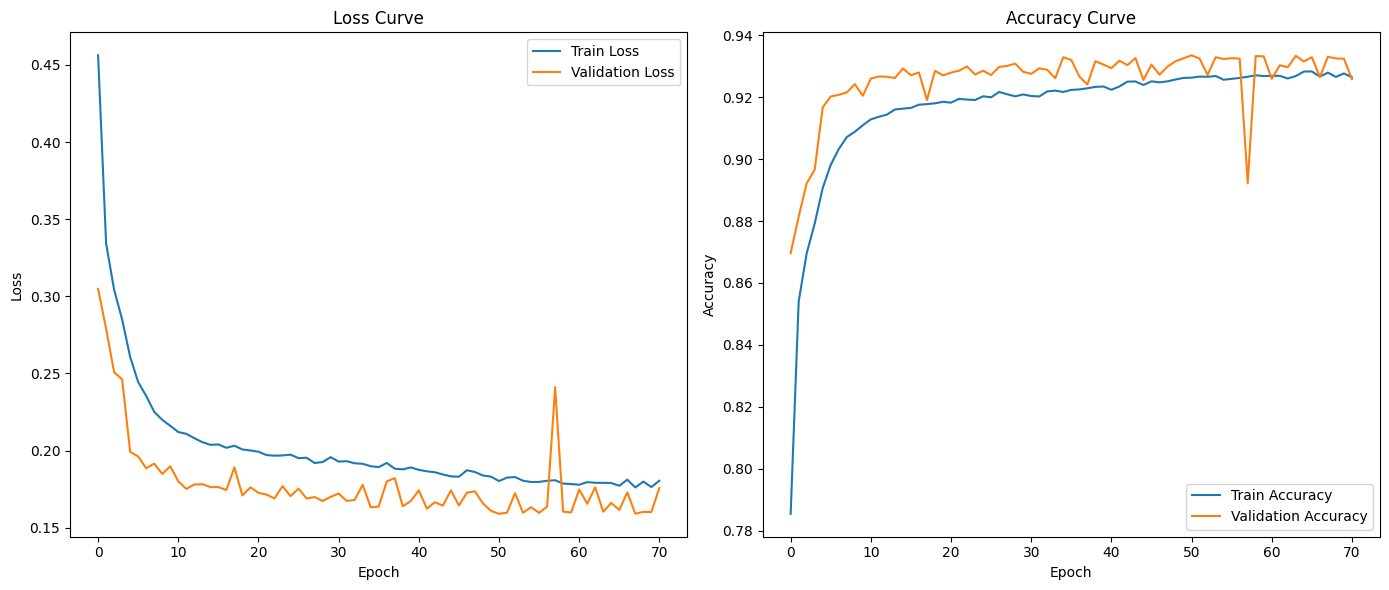

In [14]:
# Visualize training phase: Loss and Accuracy curves
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Save model

In [16]:
# Save complete model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': trainer.optimizer.state_dict(),
    'scaler': scaler,
    'label_encoders': preprocessor.label_encoders,
    'feature_columns': preprocessor.feature_columns,
    'best_val_loss': trainer.best_val_loss,
    'history': history
}, 'credit_risk_pytorch_model.pth')



print("✅ Model saved as 'credit_risk_pytorch_model_v1.pth'")

# Download model
from google.colab import files
files.download('credit_risk_pytorch_model.pth')
print("📥 Model downloaded")


✅ Model saved as 'credit_risk_pytorch_model_v1.pth'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Model downloaded
